In [3]:
import os
print(os.getcwd())

c:\Users\iftek\Desktop\numcompute\demo


In [4]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [5]:
import numpy as np

from numcompute.tree import DecisionTreeClassifier
from numcompute.ensemble import EnsembleClassifier
from numcompute.stream import StreamTrainer
from numcompute.metrics import accuracy
from numcompute.visualise import plot_metric_over_time, compare_models

In [6]:
import csv

wine_rows = [
    [0, 14.23, 1.71, 2.43, 15.6, 127, 2.80, 3.06, 0.28, 2.29, 5.64, 1.04, 3.92, 1065],
    [0, 13.20, 1.78, 2.14, 11.2, 100, 2.65, 2.76, 0.26, 1.28, 4.38, 1.05, 3.40, 1050],
    [0, 13.16, 2.36, 2.67, 18.6, 101, 2.80, 3.24, 0.30, 2.81, 5.68, 1.03, 3.17, 1185],
    [0, 14.37, 1.95, 2.50, 16.8, 113, 3.85, 3.49, 0.24, 2.18, 7.80, 0.86, 3.45, 1480],
    [0, 13.24, 2.59, 2.87, 21.0, 118, 2.80, 2.69, 0.39, 1.82, 4.32, 1.04, 2.93, 735],
    [0, 14.20, 1.76, 2.45, 15.2, 112, 3.27, 3.39, 0.34, 1.97, 6.75, 1.05, 2.85, 1450],

    [1, 12.37, 0.94, 1.36, 10.6, 88, 1.98, 0.57, 0.28, 0.42, 1.95, 1.05, 1.82, 520],
    [1, 12.33, 1.10, 2.28, 16.0, 101, 2.05, 1.09, 0.63, 0.41, 3.27, 1.25, 1.67, 680],
    [1, 12.64, 1.36, 2.02, 16.8, 100, 2.02, 1.41, 0.53, 0.62, 5.75, 0.98, 1.59, 450],
    [1, 13.67, 1.25, 1.92, 18.0, 94, 2.10, 1.79, 0.32, 0.73, 3.80, 1.23, 2.46, 630],
    [1, 12.37, 1.13, 2.16, 19.0, 87, 3.50, 3.10, 0.19, 1.87, 4.45, 1.22, 2.87, 420],
    [1, 12.17, 1.45, 2.53, 19.0, 104, 1.89, 1.75, 0.45, 1.03, 2.95, 1.45, 2.23, 355],

    [2, 13.71, 5.65, 2.45, 20.5, 95, 1.68, 0.61, 0.52, 1.06, 7.70, 0.64, 1.74, 740],
    [2, 13.40, 3.91, 2.48, 23.0, 102, 1.80, 0.75, 0.43, 1.41, 7.30, 0.70, 1.56, 750],
    [2, 13.27, 4.28, 2.26, 20.0, 120, 1.59, 0.69, 0.43, 1.35, 10.20, 0.59, 1.56, 835],
    [2, 13.17, 2.59, 2.37, 20.0, 120, 1.65, 0.68, 0.53, 1.46, 9.30, 0.60, 1.62, 840],
    [2, 14.13, 4.10, 2.74, 24.5, 96, 2.05, 0.76, 0.56, 1.35, 9.20, 0.61, 1.60, 560],
    [2, 13.45, 3.70, 2.60, 23.0, 111, 1.70, 0.92, 0.43, 1.46, 10.68, 0.85, 1.56, 695],
]

header = [
    "class", "alcohol", "malic_acid", "ash", "alcalinity_of_ash",
    "magnesium", "total_phenols", "flavanoids", "nonflavanoid_phenols",
    "proanthocyanins", "color_intensity", "hue",
    "od280_od315", "proline"
]

with open("wine_stream.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(header)
    writer.writerows(wine_rows)

print("wine_stream.csv created")

wine_stream.csv created


In [7]:
from numcompute.io import read_csv

data = read_csv("wine_stream.csv")

print(data.keys())

dict_keys(['class', 'alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280_od315', 'proline'])


In [8]:
X = np.column_stack([
    data["alcohol"],
    data["malic_acid"],
    data["ash"],
    data["alcalinity_of_ash"],
    data["magnesium"],
    data["total_phenols"],
    data["flavanoids"],
    data["nonflavanoid_phenols"],
    data["proanthocyanins"],
    data["color_intensity"],
    data["hue"],
    data["od280_od315"],
    data["proline"],
])

y = data["class"].astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", np.unique(y))

X shape: (18, 13)
y shape: (18,)
Classes: [0 1 2]


In [9]:
rng = np.random.default_rng(42)
indices = rng.permutation(len(X))

X = X[indices]
y = y[indices]

In [10]:
chunk_size = 3

chunks = []

for start in range(0, len(X), chunk_size):
    end = start + chunk_size
    chunks.append((X[start:end], y[start:end]))

print("Number of chunks:", len(chunks))

Number of chunks: 6


In [11]:
from numcompute.tree import DecisionTreeClassifier
from numcompute.ensemble import EnsembleClassifier
from numcompute.stream import StreamTrainer
from numcompute.metrics import accuracy
from numcompute.visualise import plot_metric_over_time, compare_models

In [12]:
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_trainer = StreamTrainer(tree)

tree_accuracies = []

for i, (X_chunk, y_chunk) in enumerate(chunks):
    if i == 0:
        tree_trainer.fit_chunk(X_chunk, y_chunk)
        continue

    acc = tree_trainer.score_chunk(X_chunk, y_chunk)
    tree_accuracies.append(acc)

    tree_trainer.fit_chunk(X_chunk, y_chunk)

print("Tree prequential accuracies:", tree_accuracies)

Tree prequential accuracies: [0.0, 0.3333333333333333, 1.0, 0.3333333333333333, 1.0]


In [13]:
ensemble = EnsembleClassifier(
    n_estimators=7,
    max_depth=3,
    random_state=42
)

ensemble_trainer = StreamTrainer(ensemble)

ensemble_accuracies = []

for i, (X_chunk, y_chunk) in enumerate(chunks):
    if i == 0:
        ensemble_trainer.fit_chunk(X_chunk, y_chunk)
        continue

    acc = ensemble_trainer.score_chunk(X_chunk, y_chunk)
    ensemble_accuracies.append(acc)

    ensemble_trainer.fit_chunk(X_chunk, y_chunk)

print("Ensemble prequential accuracies:", ensemble_accuracies)

Ensemble prequential accuracies: [0.0, 0.3333333333333333, 1.0, 1.0, 1.0]


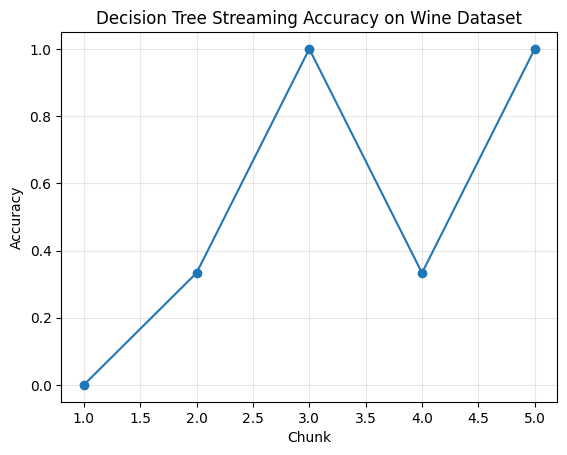

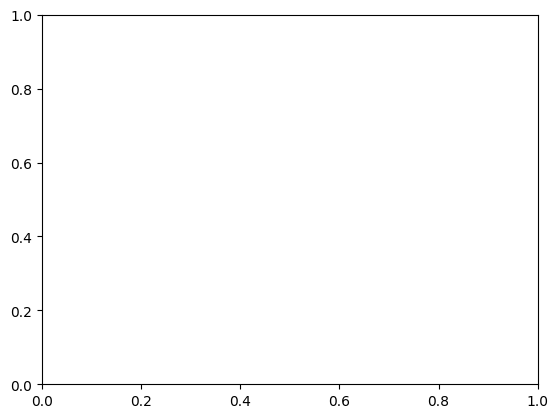

In [16]:
_ = plot_metric_over_time(
    tree_accuracies,
    title="Decision Tree Streaming Accuracy on Wine Dataset",
    ylabel="Accuracy",
    show=True
)

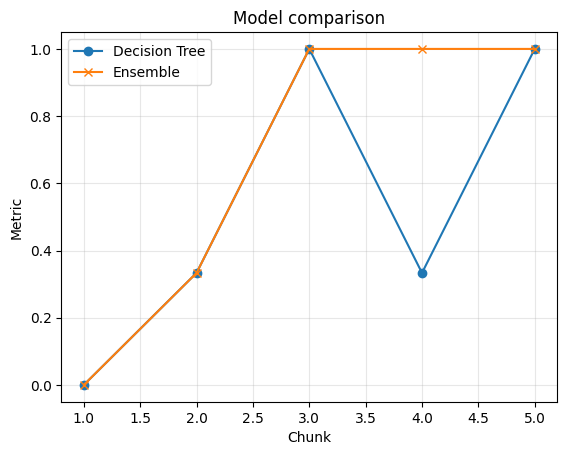

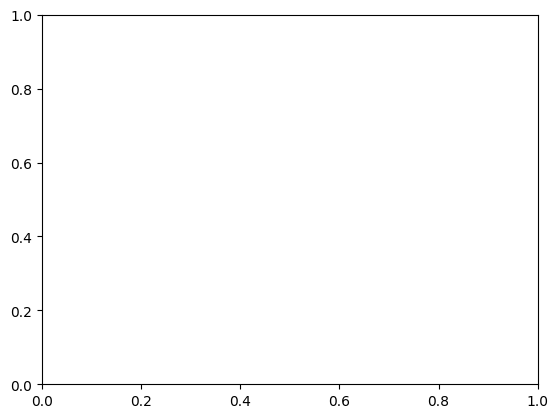

In [17]:
_ = compare_models(
    tree_accuracies,
    ensemble_accuracies,
    labels=("Decision Tree", "Ensemble"),
    show=True
)

In [18]:
tree_preds = tree.predict(X)
ensemble_preds = ensemble.predict(X)

print("Tree final accuracy:", accuracy(y, tree_preds))
print("Ensemble final accuracy:", accuracy(y, ensemble_preds))

Tree final accuracy: 1.0
Ensemble final accuracy: 1.0


### Observations

Both models initially perform poorly due to limited training data. As additional chunks are streamed, performance improves significantly. The EnsembleClassifier demonstrates more stable behaviour than the DecisionTreeClassifier, maintaining perfect accuracy on later chunks where the single tree temporarily drops in performance. This suggests that combining multiple trees reduces variance and improves robustness during streaming learning.